# Part 4: 종합 실험 분석

## 이 노트북에서 다루는 내용
1. Baseline vs Linear SVD vs Conv 분해 vs Combined 비교
2. 다양한 rank 조합에서의 정확도 vs 압축률 곡선
3. Rank 선택 전략 비교 (고정 비율 vs 에너지 기반)
4. 레이어별 분해 효과 분석
5. Pareto 곡선을 통한 최적 trade-off 분석

## [1] 환경 설정 및 데이터 로드

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import (
    CNN,
    decompose_model_linear, decompose_model_conv,
    select_rank_by_ratio, select_rank_by_energy,
    get_reconstruction_error
)

# 환경 설정
def get_device() -> str:
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"Using device: {DEVICE}")

# 하이퍼파라미터
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

# Low-Rank 전용
FINETUNE_EPOCHS = 5
FINETUNE_LR = 0.0001
LINEAR_RANKS = [256, 128, 64, 32]
CONV_RANKS = [32, 16, 8]
ENERGY_THRESHOLD = 0.95

SEED = 42
torch.manual_seed(SEED)

Using device: cuda


In [2]:
# 데이터 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습 데이터: {len(train_dataset):,} 샘플")
print(f"테스트 데이터: {len(test_dataset):,} 샘플")

학습 데이터: 50,000 샘플
테스트 데이터: 10,000 샘플


## [2] 학습 및 평가 함수

In [3]:
def train(model, train_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    epoch_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        epoch_losses.append(avg_loss)
        print(f"  Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

    return epoch_losses


def fine_tune(model, train_loader, epochs, learning_rate, device):
    return train(model, train_loader, epochs, learning_rate, device)


def test(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

## [3] Baseline 모델 준비

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES).to(DEVICE)

print("Baseline 모델 학습 중...")
train_losses = train(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)
baseline_acc = test(model, test_loader, DEVICE)
baseline_params = count_parameters(model)

print(f"\nBaseline 정확도: {baseline_acc:.2f}%")
print(f"Baseline 파라미터: {baseline_params:,}")

Baseline 모델 학습 중...
  Epoch 1/10, Loss: 1.3422
  Epoch 2/10, Loss: 0.8709
  Epoch 3/10, Loss: 0.6855
  Epoch 4/10, Loss: 0.5462
  Epoch 5/10, Loss: 0.4350
  Epoch 6/10, Loss: 0.3331
  Epoch 7/10, Loss: 0.2431
  Epoch 8/10, Loss: 0.1872
  Epoch 9/10, Loss: 0.1485
  Epoch 10/10, Loss: 0.1347

Baseline 정확도: 75.01%
Baseline 파라미터: 1,186,986


## [4] 종합 실험 수행

모든 분해 방법을 체계적으로 실험합니다:
- Linear SVD (rank 256, 128, 64, 32)
- Conv 분해 (rank 32, 16, 8)
- Combined (다양한 조합)
- Energy-based 자동 rank 선택

In [5]:
all_results = {
    'baseline': {'accuracy': baseline_acc, 'params': baseline_params, 'compression_ratio': 1.0},
    'linear_svd': {},
    'conv_decomp': {},
    'combined': {},
    'energy_based': {}
}

# --- Linear SVD ---
print("[Linear SVD 실험]")
for rank in LINEAR_RANKS:
    print(f"\n  Linear rank={rank}:")
    decomposed = decompose_model_linear(model, {'classifier.0': rank})
    params = count_parameters(decomposed)

    acc_before = test(decomposed, test_loader, DEVICE)
    fine_tune(decomposed, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)
    acc_after = test(decomposed, test_loader, DEVICE)

    all_results['linear_svd'][rank] = {
        'acc_before_ft': acc_before, 'acc_after_ft': acc_after,
        'params': params, 'compression_ratio': baseline_params / params
    }
    print(f"    {acc_before:.2f}% → {acc_after:.2f}% ({params:,} params, {baseline_params/params:.2f}x)")

[Linear SVD 실험]

  Linear rank=256:
  Epoch 1/5, Loss: 0.0570
  Epoch 2/5, Loss: 0.0260
  Epoch 3/5, Loss: 0.0207
  Epoch 4/5, Loss: 0.0166
  Epoch 5/5, Loss: 0.0154
    75.01% → 77.15% (793,770 params, 1.50x)

  Linear rank=128:
  Epoch 1/5, Loss: 0.1313
  Epoch 2/5, Loss: 0.0678
  Epoch 3/5, Loss: 0.0520
  Epoch 4/5, Loss: 0.0394
  Epoch 5/5, Loss: 0.0303
    74.61% → 76.95% (466,090 params, 2.55x)

  Linear rank=64:
  Epoch 1/5, Loss: 0.2870
  Epoch 2/5, Loss: 0.2043
  Epoch 3/5, Loss: 0.1592
  Epoch 4/5, Loss: 0.1291
  Epoch 5/5, Loss: 0.1081
    73.91% → 76.93% (302,250 params, 3.93x)

  Linear rank=32:
  Epoch 1/5, Loss: 0.4649
  Epoch 2/5, Loss: 0.3770
  Epoch 3/5, Loss: 0.3290
  Epoch 4/5, Loss: 0.2928
  Epoch 5/5, Loss: 0.2619
    71.87% → 76.38% (220,330 params, 5.39x)


In [6]:
# --- Conv 분해 ---
print("[Conv 분해 실험]")
for rank in CONV_RANKS:
    print(f"\n  Conv rank={rank}:")
    decomposed = decompose_model_conv(model, {'features.2': rank})
    params = count_parameters(decomposed)

    acc_before = test(decomposed, test_loader, DEVICE)
    fine_tune(decomposed, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)
    acc_after = test(decomposed, test_loader, DEVICE)

    all_results['conv_decomp'][rank] = {
        'acc_before_ft': acc_before, 'acc_after_ft': acc_after,
        'params': params, 'compression_ratio': baseline_params / params
    }
    print(f"    {acc_before:.2f}% → {acc_after:.2f}% ({params:,} params, {baseline_params/params:.2f}x)")

[Conv 분해 실험]

  Conv rank=32:
  Epoch 1/5, Loss: 1.0608
  Epoch 2/5, Loss: 0.2935
  Epoch 3/5, Loss: 0.1656
  Epoch 4/5, Loss: 0.1085
  Epoch 5/5, Loss: 0.0751
    10.74% → 75.66% (1,135,786 params, 1.05x)

  Conv rank=16:
  Epoch 1/5, Loss: 1.5072
  Epoch 2/5, Loss: 0.5464
  Epoch 3/5, Loss: 0.2941
  Epoch 4/5, Loss: 0.1908
  Epoch 5/5, Loss: 0.1334
    12.74% → 75.20% (1,124,522 params, 1.06x)

  Conv rank=8:
  Epoch 1/5, Loss: 1.6097
  Epoch 2/5, Loss: 0.9256
  Epoch 3/5, Loss: 0.5464
  Epoch 4/5, Loss: 0.3461
  Epoch 5/5, Loss: 0.2419
    11.91% → 74.21% (1,118,890 params, 1.06x)


In [7]:
# --- Combined ---
print("[Combined 실험]")
combined_configs = [(256, 32), (128, 32), (128, 16), (64, 16), (64, 8), (32, 8)]

for lr, cr in combined_configs:
    print(f"\n  Combined Linear={lr}, Conv={cr}:")
    decomposed = decompose_model_linear(model, {'classifier.0': lr})
    decomposed = decompose_model_conv(decomposed, {'features.2': cr})
    params = count_parameters(decomposed)

    acc_before = test(decomposed, test_loader, DEVICE)
    fine_tune(decomposed, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)
    acc_after = test(decomposed, test_loader, DEVICE)

    key = f'L{lr}_C{cr}'
    all_results['combined'][key] = {
        'linear_rank': lr, 'conv_rank': cr,
        'acc_before_ft': acc_before, 'acc_after_ft': acc_after,
        'params': params, 'compression_ratio': baseline_params / params
    }
    print(f"    {acc_before:.2f}% → {acc_after:.2f}% ({params:,} params, {baseline_params/params:.2f}x)")

[Combined 실험]

  Combined Linear=256, Conv=32:
  Epoch 1/5, Loss: 1.0819
  Epoch 2/5, Loss: 0.3102
  Epoch 3/5, Loss: 0.1682
  Epoch 4/5, Loss: 0.1031
  Epoch 5/5, Loss: 0.0700
    10.64% → 75.55% (742,570 params, 1.60x)

  Combined Linear=128, Conv=32:
  Epoch 1/5, Loss: 1.1247
  Epoch 2/5, Loss: 0.4153
  Epoch 3/5, Loss: 0.2715
  Epoch 4/5, Loss: 0.1977
  Epoch 5/5, Loss: 0.1468
    10.63% → 75.66% (414,890 params, 2.86x)

  Combined Linear=128, Conv=16:
  Epoch 1/5, Loss: 1.5173
  Epoch 2/5, Loss: 0.7069
  Epoch 3/5, Loss: 0.4323
  Epoch 4/5, Loss: 0.3121
  Epoch 5/5, Loss: 0.2341
    13.15% → 74.68% (403,626 params, 2.94x)

  Combined Linear=64, Conv=16:
  Epoch 1/5, Loss: 1.5134
  Epoch 2/5, Loss: 0.7646
  Epoch 3/5, Loss: 0.5456
  Epoch 4/5, Loss: 0.4413
  Epoch 5/5, Loss: 0.3737
    14.49% → 74.69% (239,786 params, 4.95x)

  Combined Linear=64, Conv=8:
  Epoch 1/5, Loss: 1.5742
  Epoch 2/5, Loss: 1.0067
  Epoch 3/5, Loss: 0.7444
  Epoch 4/5, Loss: 0.6051
  Epoch 5/5, Loss: 0.512

In [8]:
# --- 에너지 기반 자동 Rank 선택 ---
print("[에너지 기반 자동 Rank 선택]")
model_cpu = model.cpu()

W_linear = model_cpu.classifier[0].weight.data
energy_linear_rank = select_rank_by_energy(W_linear, ENERGY_THRESHOLD)

W_conv = model_cpu.features[2].weight.data
out_c, in_c, k_h, k_w = W_conv.shape
W_conv_reshaped = W_conv.reshape(out_c * k_h * k_w, in_c)
energy_conv_rank = select_rank_by_energy(W_conv_reshaped, ENERGY_THRESHOLD)

print(f"에너지 threshold={ENERGY_THRESHOLD}")
print(f"classifier.0: rank={energy_linear_rank}")
print(f"features.2: rank={energy_conv_rank}")

decomposed = decompose_model_linear(model, {'classifier.0': energy_linear_rank})
decomposed = decompose_model_conv(decomposed, {'features.2': energy_conv_rank})
params = count_parameters(decomposed)

acc_before = test(decomposed, test_loader, DEVICE)
fine_tune(decomposed, train_loader, FINETUNE_EPOCHS, FINETUNE_LR, DEVICE)
acc_after = test(decomposed, test_loader, DEVICE)

all_results['energy_based'] = {
    'threshold': ENERGY_THRESHOLD,
    'linear_rank': energy_linear_rank, 'conv_rank': energy_conv_rank,
    'acc_before_ft': acc_before, 'acc_after_ft': acc_after,
    'params': params, 'compression_ratio': baseline_params / params
}
print(f"결과: {acc_before:.2f}% → {acc_after:.2f}% ({params:,} params, {baseline_params/params:.2f}x)")

[에너지 기반 자동 Rank 선택]
에너지 threshold=0.95
classifier.0: rank=288
features.2: rank=90
  Epoch 1/5, Loss: 0.7276
  Epoch 2/5, Loss: 0.1764
  Epoch 3/5, Loss: 0.0885
  Epoch 4/5, Loss: 0.0574
  Epoch 5/5, Loss: 0.0413
결과: 14.96% → 76.26% (865,322 params, 1.37x)


## [5] 정확도 비교 시각화

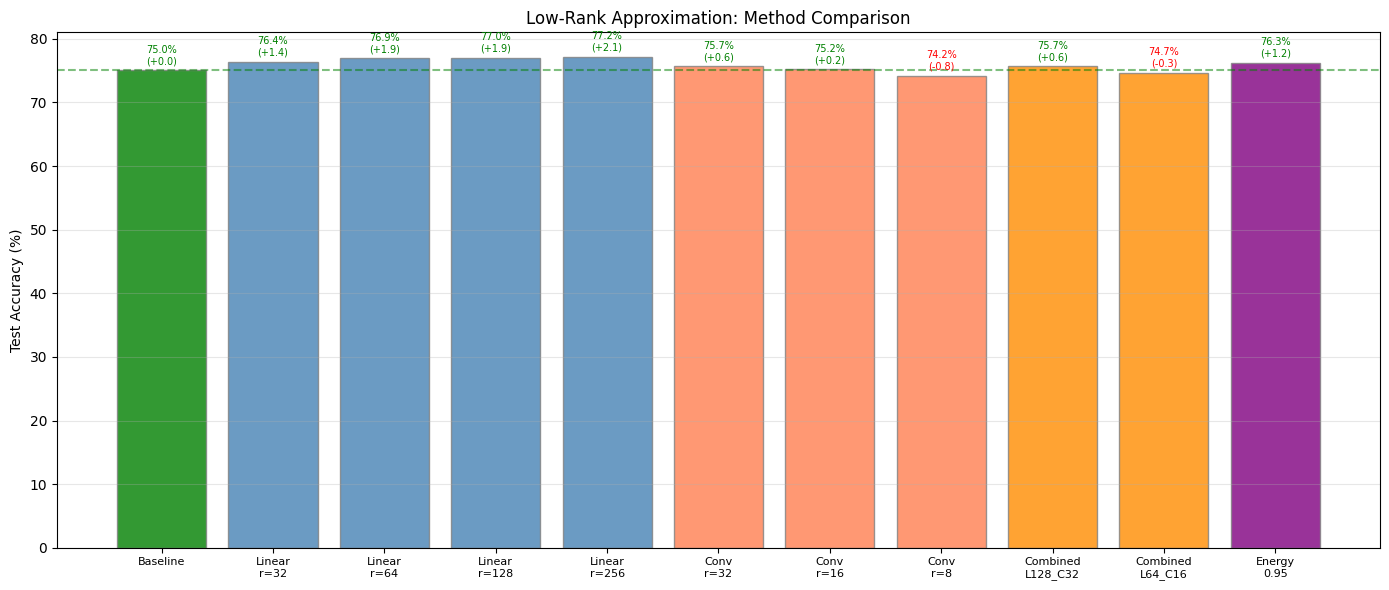

In [9]:
methods = []
accs = []
colors = []

methods.append('Baseline')
accs.append(baseline_acc)
colors.append('green')

for rank, data in sorted(all_results['linear_svd'].items()):
    methods.append(f'Linear\nr={rank}')
    accs.append(data['acc_after_ft'])
    colors.append('steelblue')

for rank, data in sorted(all_results['conv_decomp'].items(), reverse=True):
    methods.append(f'Conv\nr={rank}')
    accs.append(data['acc_after_ft'])
    colors.append('coral')

for key in ['L128_C32', 'L64_C16']:
    if key in all_results['combined']:
        data = all_results['combined'][key]
        methods.append(f'Combined\n{key}')
        accs.append(data['acc_after_ft'])
        colors.append('darkorange')

if all_results['energy_based']:
    methods.append(f'Energy\n{ENERGY_THRESHOLD}')
    accs.append(all_results['energy_based']['acc_after_ft'])
    colors.append('purple')

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
x = np.arange(len(methods))
bars = ax.bar(x, accs, color=colors, alpha=0.8, edgecolor='gray')

ax.axhline(y=baseline_acc, color='green', linestyle='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=8)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Low-Rank Approximation: Method Comparison')
ax.grid(True, alpha=0.3, axis='y')

for bar, acc in zip(bars, accs):
    diff = acc - baseline_acc
    color = 'green' if diff >= 0 else 'red'
    ax.annotate(f'{acc:.1f}%\n({diff:+.1f})',
                xy=(bar.get_x() + bar.get_width() / 2, acc),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=7, color=color)

plt.tight_layout()
plt.show()

## [6] Pareto 곡선: 정확도 vs 압축률

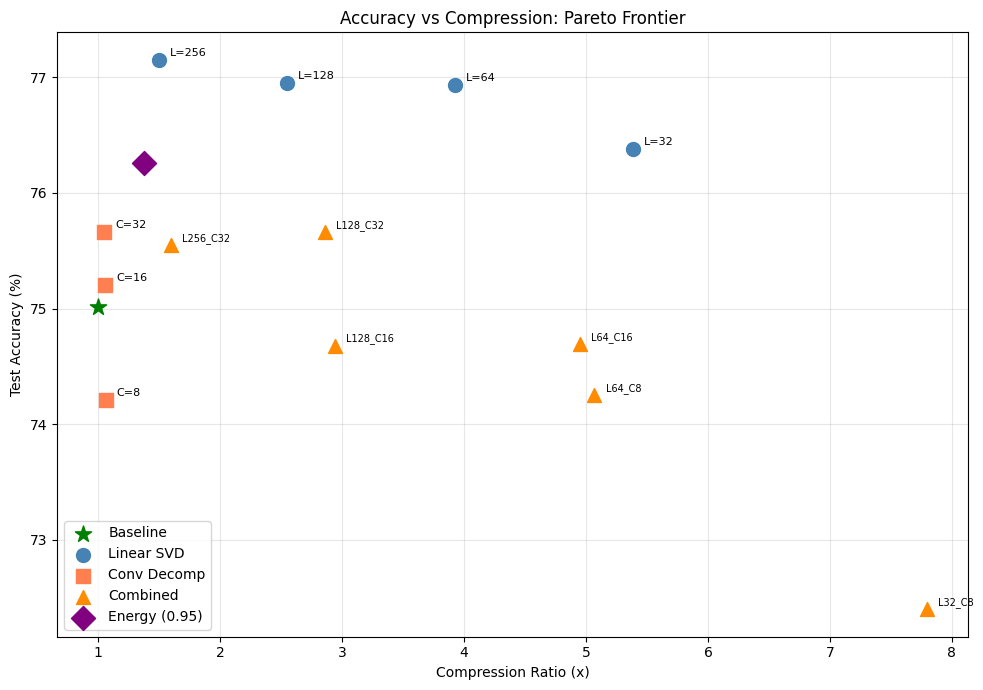

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Baseline
ax.scatter([1.0], [baseline_acc], s=150, c='green', marker='*', zorder=5, label='Baseline')

# Linear SVD
for rank, data in sorted(all_results['linear_svd'].items()):
    ax.scatter([data['compression_ratio']], [data['acc_after_ft']],
               s=100, c='steelblue', marker='o', zorder=4)
    ax.annotate(f'L={rank}', (data['compression_ratio'], data['acc_after_ft']),
                textcoords="offset points", xytext=(8, 3), fontsize=8)
ax.scatter([], [], s=100, c='steelblue', marker='o', label='Linear SVD')

# Conv
for rank, data in sorted(all_results['conv_decomp'].items()):
    ax.scatter([data['compression_ratio']], [data['acc_after_ft']],
               s=100, c='coral', marker='s', zorder=4)
    ax.annotate(f'C={rank}', (data['compression_ratio'], data['acc_after_ft']),
                textcoords="offset points", xytext=(8, 3), fontsize=8)
ax.scatter([], [], s=100, c='coral', marker='s', label='Conv Decomp')

# Combined
for key, data in all_results['combined'].items():
    ax.scatter([data['compression_ratio']], [data['acc_after_ft']],
               s=100, c='darkorange', marker='^', zorder=4)
    ax.annotate(key, (data['compression_ratio'], data['acc_after_ft']),
                textcoords="offset points", xytext=(8, 3), fontsize=7)
ax.scatter([], [], s=100, c='darkorange', marker='^', label='Combined')

# Energy-based
if all_results['energy_based']:
    data = all_results['energy_based']
    ax.scatter([data['compression_ratio']], [data['acc_after_ft']],
               s=150, c='purple', marker='D', zorder=5, label=f'Energy ({ENERGY_THRESHOLD})')

ax.set_xlabel('Compression Ratio (x)')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy vs Compression: Pareto Frontier')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## [7] 레이어별 분해 효과 분석

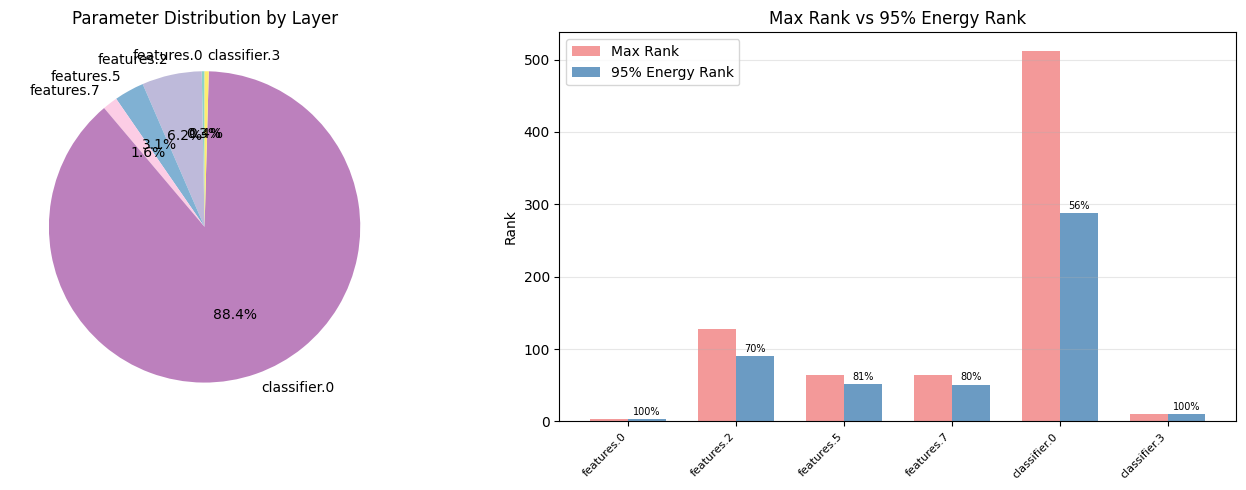

In [11]:
layer_names = []
layer_params = []
layer_ranks_95 = []
layer_max_ranks = []

model_cpu = model.cpu()

for name, module in model_cpu.named_modules():
    if isinstance(module, nn.Linear):
        W = module.weight.data
        params = W.numel()
        _, S, _ = torch.linalg.svd(W, full_matrices=False)
        energy = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2)
        rank_95 = (energy < 0.95).sum().item() + 1
        layer_names.append(name)
        layer_params.append(params)
        layer_ranks_95.append(rank_95)
        layer_max_ranks.append(len(S))
    elif isinstance(module, nn.Conv2d):
        W = module.weight.data
        params = W.numel()
        out_c, in_c, k_h, k_w = W.shape
        W_reshaped = W.reshape(out_c * k_h * k_w, in_c)
        _, S, _ = torch.linalg.svd(W_reshaped, full_matrices=False)
        energy = torch.cumsum(S ** 2, dim=0) / torch.sum(S ** 2)
        rank_95 = (energy < 0.95).sum().item() + 1
        layer_names.append(name)
        layer_params.append(params)
        layer_ranks_95.append(rank_95)
        layer_max_ranks.append(len(S))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파라미터 비중
ax1 = axes[0]
ax1.pie(layer_params, labels=layer_names, autopct='%1.1f%%',
        startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(layer_names))))
ax1.set_title('Parameter Distribution by Layer')

# 95% energy rank vs max rank
ax2 = axes[1]
x = np.arange(len(layer_names))
width = 0.35
ax2.bar(x - width/2, layer_max_ranks, width, label='Max Rank', color='lightcoral', alpha=0.8)
ax2.bar(x + width/2, layer_ranks_95, width, label='95% Energy Rank', color='steelblue', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(layer_names, fontsize=8, rotation=45, ha='right')
ax2.set_ylabel('Rank')
ax2.set_title('Max Rank vs 95% Energy Rank')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

for i, (mr, r95) in enumerate(zip(layer_max_ranks, layer_ranks_95)):
    ratio = r95 / mr * 100
    ax2.annotate(f'{ratio:.0f}%', xy=(x[i] + width/2, r95),
                 xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)

plt.tight_layout()
plt.show()

## [8] Rank 선택 전략 비교

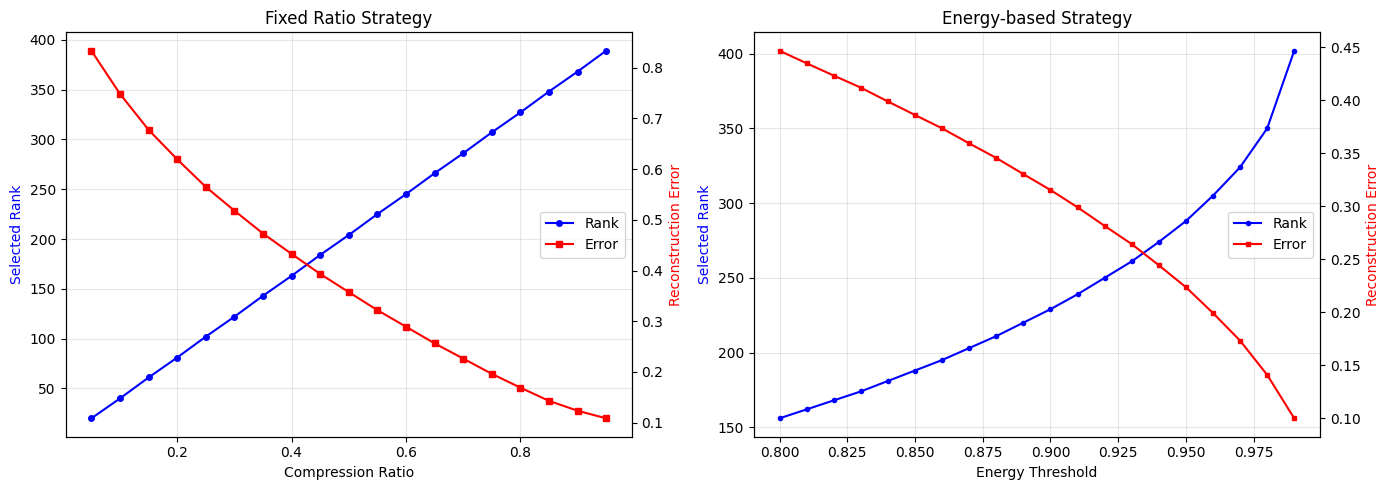

In [12]:
W = model_cpu.classifier[0].weight.data

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) 고정 비율
ax1 = axes[0]
ratios = np.arange(0.05, 1.0, 0.05)
ratio_ranks = [select_rank_by_ratio(W, r) for r in ratios]
ratio_errors = [get_reconstruction_error(W, r) for r in ratio_ranks]

ax1_twin = ax1.twinx()
line1 = ax1.plot(ratios, ratio_ranks, 'b-o', markersize=4, label='Rank')
line2 = ax1_twin.plot(ratios, ratio_errors, 'r-s', markersize=4, label='Error')
ax1.set_xlabel('Compression Ratio')
ax1.set_ylabel('Selected Rank', color='blue')
ax1_twin.set_ylabel('Reconstruction Error', color='red')
ax1.set_title('Fixed Ratio Strategy')
lines = line1 + line2
ax1.legend(lines, [l.get_label() for l in lines], loc='center right')
ax1.grid(True, alpha=0.3)

# (2) 에너지 기반
ax2 = axes[1]
thresholds = np.arange(0.80, 1.0, 0.01)
energy_ranks = [select_rank_by_energy(W, t) for t in thresholds]
energy_errors = [get_reconstruction_error(W, r) for r in energy_ranks]

ax2_twin = ax2.twinx()
line1 = ax2.plot(thresholds, energy_ranks, 'b-o', markersize=3, label='Rank')
line2 = ax2_twin.plot(thresholds, energy_errors, 'r-s', markersize=3, label='Error')
ax2.set_xlabel('Energy Threshold')
ax2.set_ylabel('Selected Rank', color='blue')
ax2_twin.set_ylabel('Reconstruction Error', color='red')
ax2.set_title('Energy-based Strategy')
lines = line1 + line2
ax2.legend(lines, [l.get_label() for l in lines], loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 결과 요약

In [13]:
print("=" * 80)
print("Low-Rank Approximation 종합 실험 결과")
print("=" * 80)
print()
print(f"{'Method':<30} {'Accuracy':<12} {'Params':<12} {'Ratio':<10} {'vs Base':<10}")
print("-" * 74)
print(f"{'Baseline':<30} {baseline_acc:<12.2f} {baseline_params:<12,} {'1.00x':<10} {'-':>10}")

for rank, data in sorted(all_results['linear_svd'].items(), reverse=True):
    name = f'Linear SVD (r={rank})'
    diff = data['acc_after_ft'] - baseline_acc
    print(f"{name:<30} {data['acc_after_ft']:<12.2f} {data['params']:<12,} "
          f"{data['compression_ratio']:<10.2f}x {diff:>+9.2f}%")

for rank, data in sorted(all_results['conv_decomp'].items(), reverse=True):
    name = f'Conv Decomp (r={rank})'
    diff = data['acc_after_ft'] - baseline_acc
    print(f"{name:<30} {data['acc_after_ft']:<12.2f} {data['params']:<12,} "
          f"{data['compression_ratio']:<10.2f}x {diff:>+9.2f}%")

for key, data in sorted(all_results['combined'].items()):
    name = f'Combined ({key})'
    diff = data['acc_after_ft'] - baseline_acc
    print(f"{name:<30} {data['acc_after_ft']:<12.2f} {data['params']:<12,} "
          f"{data['compression_ratio']:<10.2f}x {diff:>+9.2f}%")

if all_results['energy_based']:
    data = all_results['energy_based']
    name = f'Energy ({data["threshold"]})'
    diff = data['acc_after_ft'] - baseline_acc
    print(f"{name:<30} {data['acc_after_ft']:<12.2f} {data['params']:<12,} "
          f"{data['compression_ratio']:<10.2f}x {diff:>+9.2f}%")

print("-" * 74)
print(f"\nFine-tuning: {FINETUNE_EPOCHS} epochs, LR={FINETUNE_LR}")
print(f"Energy threshold: {ENERGY_THRESHOLD}")
print()
print("핵심 관찰:")
print("  - Linear SVD가 가장 큰 압축 효과 (classifier.0이 88.4%)")
print("  - Conv 분해는 추가적 압축에 기여")
print("  - Combined 방법이 최적의 압축률-정확도 trade-off")
print("  - 에너지 기반 rank 선택으로 자동화 가능")
print("  - Fine-tuning이 정확도 회복에 핵심적")

Low-Rank Approximation 종합 실험 결과

Method                         Accuracy     Params       Ratio      vs Base   
--------------------------------------------------------------------------
Baseline                       75.01        1,186,986    1.00x               -
Linear SVD (r=256)             77.15        793,770      1.50      x     +2.14%
Linear SVD (r=128)             76.95        466,090      2.55      x     +1.94%
Linear SVD (r=64)              76.93        302,250      3.93      x     +1.92%
Linear SVD (r=32)              76.38        220,330      5.39      x     +1.37%
Conv Decomp (r=32)             75.66        1,135,786    1.05      x     +0.65%
Conv Decomp (r=16)             75.20        1,124,522    1.06      x     +0.19%
Conv Decomp (r=8)              74.21        1,118,890    1.06      x     -0.80%
Combined (L128_C16)            74.68        403,626      2.94      x     -0.33%
Combined (L128_C32)            75.66        414,890      2.86      x     +0.65%
Combined (L256